# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

- Założenie biznesowe: 
Za kluczową metrykę obieram F2 score, żeby brać szczególny nacisk na Recall, czyli wykrywanie otyłości u pacjentów, ale żeby też nie wykonywać zbędnych badań, czyli precision. 

### Importy

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
)
from sklearn.pipeline import Pipeline

In [71]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/MyDrive/datasets/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(path)
df.shape


Mounted at /content/drive


(2111, 17)

### Walidacja danych


- Sprawdzenie braków

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [73]:
assert sum(df.isnull().sum()) == 0

- Nie występują braki


In [74]:
if df.duplicated().sum() != 0:
    df.drop_duplicates(inplace=True)
assert df.duplicated().sum() == 0

- Usunięto duplikaty


| Skrót zmiennej | Pełna nazwa (ang.) | Opis (pl) | Typ danych (przed mapowaniem) |
| :--- | :--- | :--- | :--- |
| **Gender** | Gender | Płeć pacjenta. | Kategoryczny (Female / Male) |
| **Age** | Age | Wiek w latach. | Numeryczny (Ciągły) |
| **Height** | Height | Wzrost w metrach. | Numeryczny (Ciągły) |
| **Weight** | Weight | Waga w kilogramach. | Numeryczny (Ciągły) |
| **family_history_with_overweight** | Family History with Overweight | Czy w najbliższej rodzinie występowały problemy z otyłością? | Kategoryczny (yes / no) |
| **FAVC** | Frequent consumption of high caloric food | Czy pacjent często spożywa wysokokaloryczne jedzenie (fast-food)? | Kategoryczny (yes / no) |
| **FCVC** | Frequency of consumption of vegetables | Częstotliwość spożywania warzyw w głównych posiłkach (od 1 do 3). | Numeryczny |
| **NCP** | Number of main meals | Liczba głównych posiłków zjadanych w ciągu dnia (od 1 do 4). | Numeryczny |
| **CAEC** | Consumption of food between meals | Częstotliwość podjadania między głównymi posiłkami. | Kategoryczny (no, Sometimes, Frequently, Always) |
| **SMOKE** | Smoke | Czy pacjent pali papierosy? | Kategoryczny (yes / no) |
| **CH2O** | Consumption of water daily | Ilość wypijanej wody dziennie (od 1 do 3 litrów). | Numeryczny |
| **SCC** | Calories consumption monitoring | Czy pacjent celowo monitoruje spożycie swoich kalorii? | Kategoryczny (yes / no) |
| **FAF** | Physical activity frequency | Częstotliwość aktywności fizycznej w ciągu tygodnia (od 0 do 3). | Numeryczny |
| **TUE** | Time using technology devices | Czas spędzany przed ekranem (telefon, TV, PC) dziennie (od 0 do 2). | Numeryczny |
| **CALC** | Consumption of alcohol | Jak często pacjent pije alkohol. | Kategoryczny (no, Sometimes, Frequently, Always) |
| **MTRANS** | Transportation used | Najczęściej używany środek transportu. | Kategoryczny (Automobile, Motorbike, Bike, Public_Transportation, Walking) |
| **NObeyesdad** | Target Variable (Obesity Level) | **ZMIENNA CELU:** Przypisana klasa wagi / otyłości (od niedowagi do otyłości 3. stopnia). | Kategoryczny (7 różnych klas) |


- Jako główną metrykę ewaluacji wybieram F2-score, ponieważ w tym problemie medycznym musimy znaleźć złoty środek. Musimy jednocześnie minimalizować ryzyko przeoczenia pacjentów zagrożonych otyłością (co maksymalizuje metryka Recall), jak i unikać fałszywych alarmów, które prowadziłyby do marnowania publicznych zasobów na profilaktykę osób zdrowych (co optymalizuje metryka Precision).



In [75]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'no': 0, 'yes': 1})
df['FAVC'] = df['FAVC'].map({'no': 0, 'yes': 1}) 
df['SMOKE'] = df['SMOKE'].map({'no': 0, 'yes': 1})
df['SCC'] = df['SCC'].map({'no': 0, 'yes': 1})

df['CAEC'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df['CALC'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS')

df['NObeyesdad'] = df['NObeyesdad'].map({
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
})


- Zastąpiłem zmienne kategoryczne wartościami 0, 1. Jeżeli chodzi o zmienne, które są sobie pokrewne zastosowałem Ordinal Encoding. W przypadku środków transportu trzeba było użyć One-Hot Encoding, ponieważ jazda rowerem, a chodzenie pieszo nie ma nic ze sobą wspólnego pod kątem uporządkowania danych.

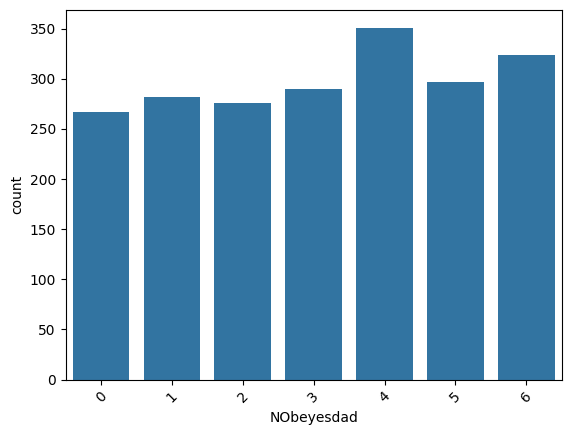

In [76]:
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.show()

- Zbiór jest zbalansowany pod kątem zmiennej celu, więc nie trzeba używać SMOTE'a. 

### Badanie korelacji

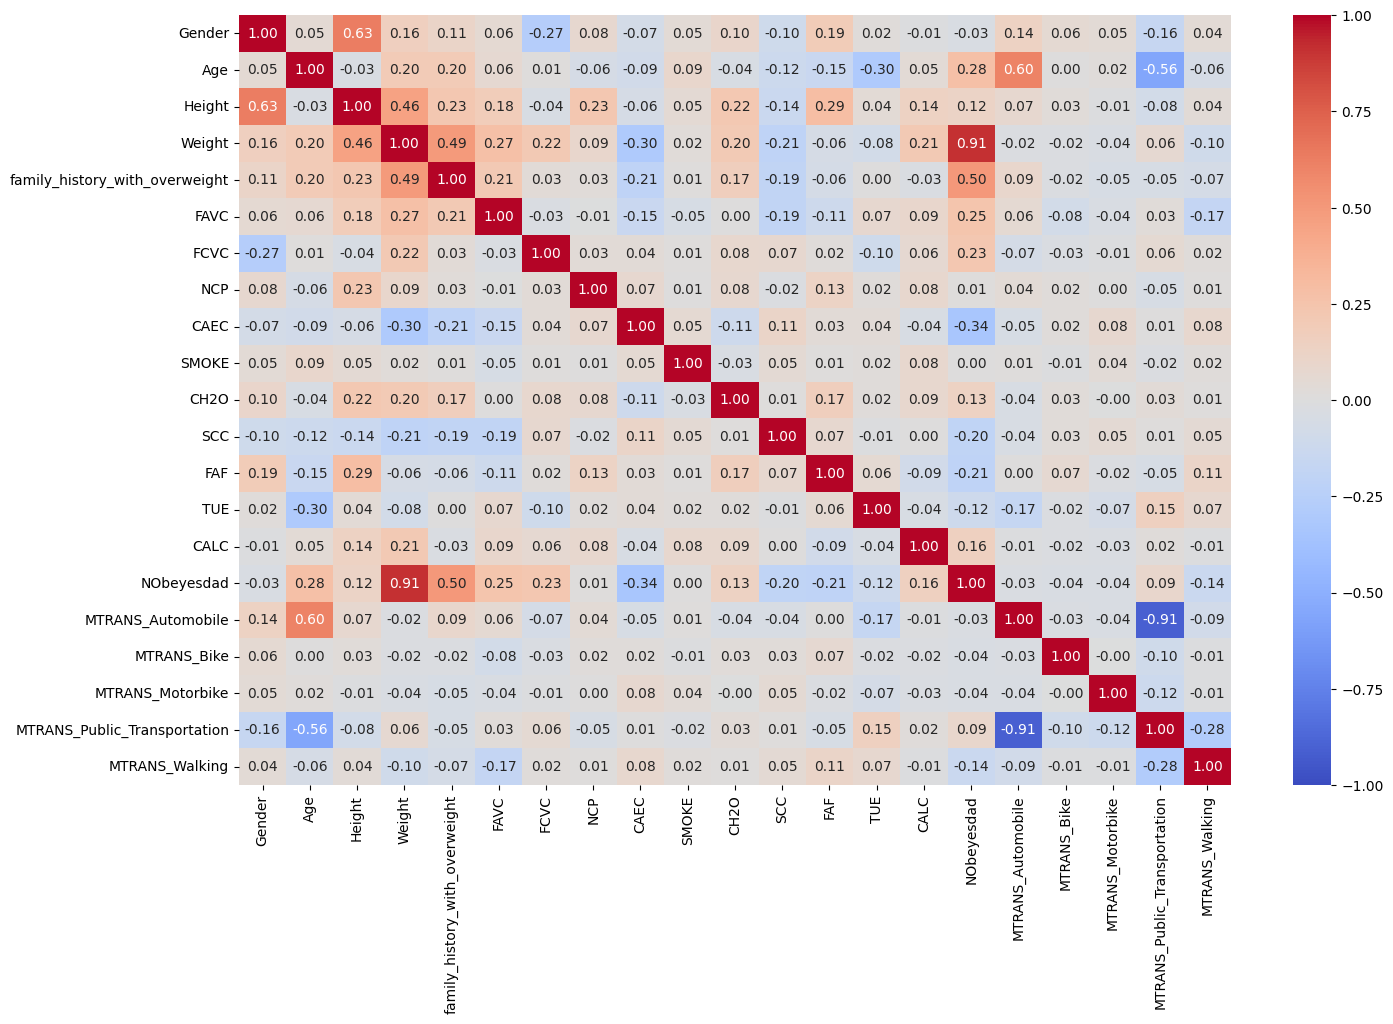

In [77]:
plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), vmin = -1, vmax = 1 , cmap = "coolwarm", annot = True, fmt= ".2f")
plt.show()

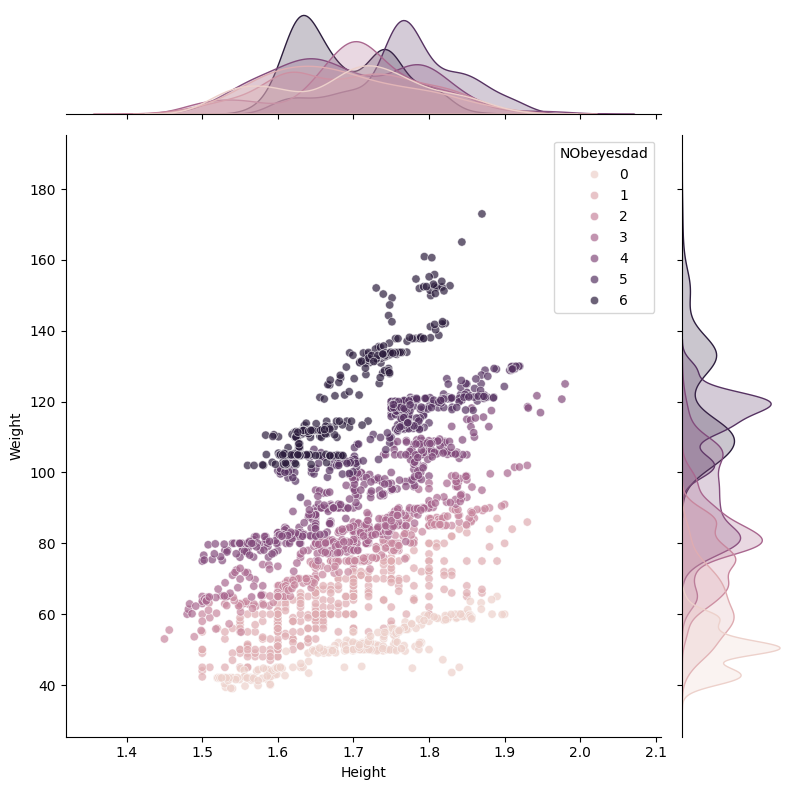

In [78]:
sns.jointplot(x='Height', y='Weight', data=df, hue='NObeyesdad', height=8, alpha=0.7)

- Ze wzrostem zwiększa się waga, i ponadto wraz z wagą zwiększa się stopień otyłości.

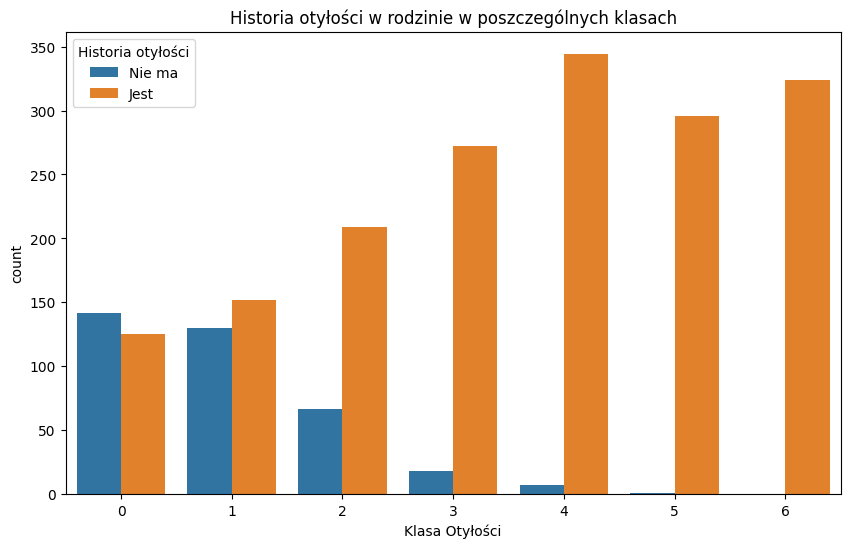

In [79]:
plt.figure(figsize=(10, 6))
sns.countplot(x='NObeyesdad', hue='family_history_with_overweight', data=df)
plt.title('Historia otyłości w rodzinie w poszczególnych klasach')
plt.xlabel('Klasa Otyłości')
plt.legend(title='Historia otyłości', labels=['Nie ma', 'Jest'])
plt.show()

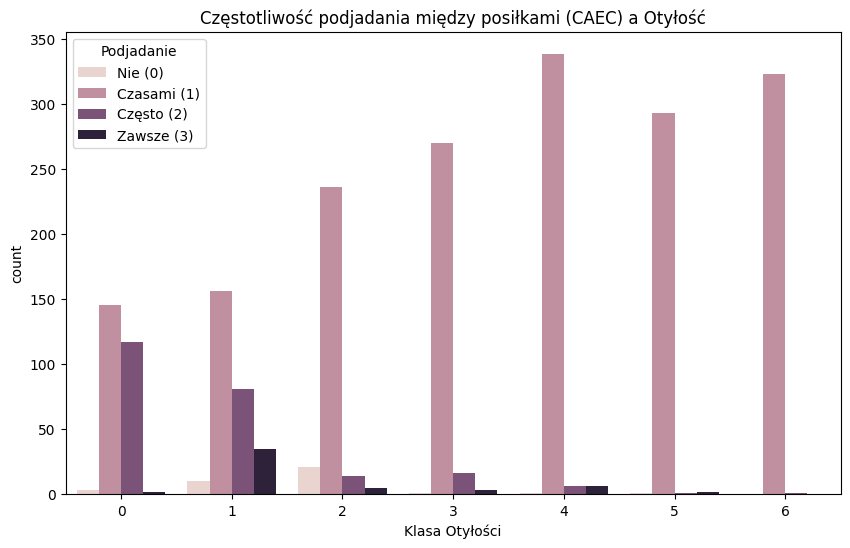

In [80]:
plt.figure(figsize=(10, 6))
sns.countplot(x='NObeyesdad', hue='CAEC', data=df)
plt.title('Częstotliwość podjadania między posiłkami (CAEC) a Otyłość')
plt.xlabel('Klasa Otyłości')
plt.legend(title='Podjadanie', labels=['Nie (0)', 'Czasami (1)', 'Często (2)', 'Zawsze (3)'])
plt.show()

- Im więcej ktoś podjada, tym znajduje się w niższym stadium otyłości.

### Podział danych


In [81]:
X = df.drop(columns = ["NObeyesdad"]).copy()
y = df["NObeyesdad"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 67, stratify = y)

pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter = 2000, random_state = 42))
])


### Baseline


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr')
    elif hasattr(model, "decision_function"):
        roc_auc = None
        y_score = None
    else:
        y_score = y_pred
    
    return {
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0, average='weighted'),
        "recall": recall_score(y_test, y_pred, zero_division=0, average='weighted'),
        "precision": precision_score(y_test, y_pred, zero_division=0, average='weighted'),
        "roc_auc": roc_auc,
        "pr_auc": average_precision_score(y_test, y_score,average='weighted'),
    }


In [83]:
baseline_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "dummy_stratified": DummyClassifier(strategy="stratified", random_state=42),
    "logreg_default": pipeline_logreg,
    "decision_tree": DecisionTreeClassifier(random_state = 42)
}

rows = []
for name, model in baseline_models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["model"] = name
    rows.append(metrics)

baseline_results = pd.DataFrame(rows)[
    [ "model", "f2", "recall", "precision" , "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)

baseline_results

,model,f2,recall,precision,roc_auc,pr_auc
3,decision_tree,0.940189,0.940191,0.940744,0.964541,0.894097
2,logreg_default,0.881013,0.882775,0.885204,0.983529,0.902719
1,dummy_stratified,0.136496,0.136364,0.137597,0.496491,0.145130
0,dummy_most_frequent,0.083972,0.167464,0.028044,0.500000,0.144067


- Decision Tree radzi sobie najlepiej, a druga jest regresja logistyczna pod kątem F2 score. Ponadto inne metryki wypadają bardzo dobrze.

### Bagging z GridSearchem

In [84]:
bagging = BaggingClassifier(
    estimator = DecisionTreeClassifier(random_state = 42),
    random_state = 42
)

param_grid = {
    'n_estimators': [10,20,50,100], 
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}

f2_scorer = make_scorer(fbeta_score, beta=2, average='weighted')
grid_search = GridSearchCV(
    estimator = bagging,
    param_grid = param_grid,
    cv = 5,
    scoring = f2_scorer,
    n_jobs = -1
)


grid_search.fit(X_train, y_train)

best_bagging_model = grid_search.best_estimator_
metrics_bagging = evaluate_model(best_bagging_model, X_train, y_train, X_test, y_test)
metrics_bagging["model"] = "bagging_best_grid"
print("Metryki dla najlepszego Baggingu:")
print(metrics_bagging)


Metryki dla najlepszego Baggingu:
{'f2': 0.9688665753598549, 'recall': 0.9688995215311005, 'precision': 0.9701088284879062, 'roc_auc': np.float64(0.9982544333907848), 'pr_auc': np.float64(0.9911569777425429), 'model': 'bagging_best_grid'}


- Metryki dla najlepszego Baggingu:
{'recall': 0.96, 'precision': 0.97, 'f2': 0.96, 'roc_auc': 0.99, 'pr_auc': 0.99, 'model': 'bagging_best_grid'}

### Adaboost

In [85]:
adaboost = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 3, random_state = 42))
param_grid = {
    'n_estimators': [10,20,50,100], 
    'learning_rate': [0.05, 0.1, 0.2, 0.5, 1.0],
}

f2_scorer = make_scorer(fbeta_score, beta=2, average='weighted')
grid_search = GridSearchCV(
    estimator = adaboost,
    param_grid = param_grid,
    cv = 5,
    scoring = f2_scorer,
    n_jobs = -1
)


grid_search.fit(X_train, y_train)

best_adaboost_model = grid_search.best_estimator_
metrics_adaboost = evaluate_model(best_adaboost_model, X_train, y_train, X_test, y_test)
metrics_adaboost["model"] = "adaboost_best_grid"
print("Metryki dla najlepszego adaboost:")
print(metrics_adaboost)



Metryki dla najlepszego adaboost:
{'f2': 0.932935589187423, 'recall': 0.9330143540669856, 'precision': 0.9350587922569346, 'roc_auc': np.float64(0.9883596219928089), 'pr_auc': np.float64(0.9388824884536889), 'model': 'adaboost_best_grid'}


Wyniki najlepsze to
{'recall': 0.93, 'precision': 0.93, 'f2': 0.93, 'roc_auc': 0.98, 'pr_auc': 0.94}

### GradientBoosting

In [86]:
gb = GradientBoostingClassifier(random_state = 42)

param_grid = {
    'n_estimators': [10,20,50,100], 
    'learning_rate': [0.05, 0.1, 0.2, 0.5, 1.0],
}

f2_scorer = make_scorer(fbeta_score, beta = 2 , average = "weighted")
grid_search = GridSearchCV(
    estimator = gb,
    param_grid = param_grid,
    cv = 5,
    scoring = f2_scorer,
    n_jobs = -1
)

grid_search.fit(X_train, y_train)
best_gb_model = grid_search.best_estimator_
metrics_gb = evaluate_model(best_gb_model, X_train, y_train, X_test, y_test)
metrics_gb["model"] = "gradientboost_best_grid"
print(metrics_gb) 

{'f2': 0.940207803257006, 'recall': 0.9401913875598086, 'precision': 0.9408447906273409, 'roc_auc': np.float64(0.9941530539169244), 'pr_auc': np.float64(0.9702984532770981), 'model': 'gradientboost_best_grid'}


- Wyniki dla najlepszego gradientboostingu:
{'recall': 0.94, 'precision': 0.94, 'f2': 0.94, 'roc_auc': 0.99, 'pr_auc': 0.97, 'model': 'gradientboost_best_grid'}

### VotingClassifier

In [87]:
voting = VotingClassifier(
    estimators=[
    ('logreg', baseline_models["logreg_default"]),
    ('bagging', best_bagging_model),
    ('adaboost', best_adaboost_model),
    ('gradientboosting', best_gb_model)],
    voting = 'soft'
)

metrics_voting = evaluate_model(voting, X_train, y_train , X_test, y_test)
metrics_voting["model"] = "voting"
print(metrics_voting)

{'f2': 0.9545718349945596, 'recall': 0.9545454545454546, 'precision': 0.9548652652695973, 'roc_auc': np.float64(0.9976612312155471), 'pr_auc': np.float64(0.9891604058462559), 'model': 'voting'}


- Voting przegrywa z Baggingiem. Wiele modeli nie musi przeważyć najlepszego modelu i tak w tym wypadku się dzieje.

### Ważność cech

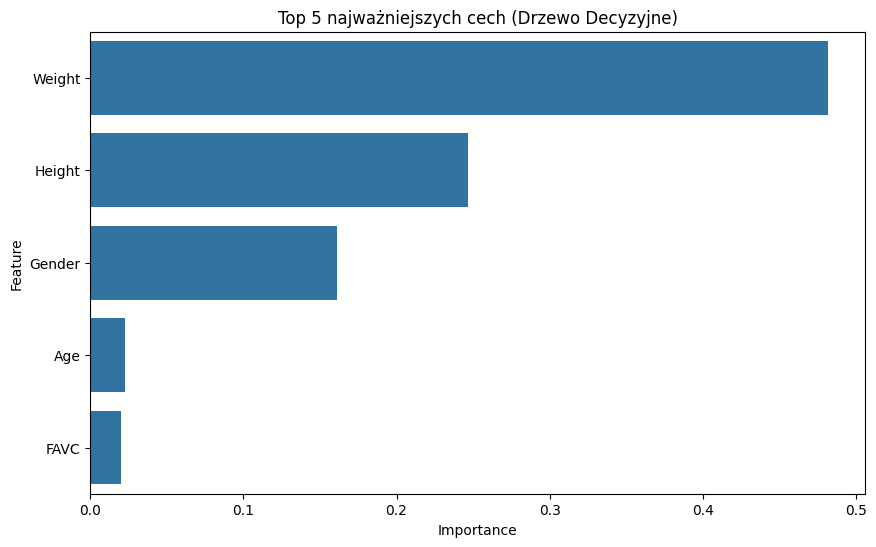

In [88]:
importances = baseline_models["decision_tree"].feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df)
plt.title("Top 5 najważniejszych cech (Drzewo Decyzyjne)")
plt.show()


### Mierzenie czasu


In [89]:
%%timeit
baseline_models["logreg_default"].predict(X_test)

3.12 ms ± 175 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [90]:
%%timeit
best_adaboost_model.predict(X_test)

29.2 ms ± 1.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [91]:
%%timeit
best_bagging_model.predict(X_test)

26.1 ms ± 1.59 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [92]:
%%timeit
best_gb_model.predict(X_test)

9.95 ms ± 1.5 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


- Najlepiej czasowo wypada regresja logistyczna, jej czas predykcji to 192 mikrosekudny, a dla gradientboosting, to 8 ms, a dla adaboost i baggingu wynosi ok 27 ms. 

### Wnioski końcowe
- Jako główną miarę wybrałem `F2`, ponieważ chcemy mieć nacisk na to by nie pomijać chorych pacjentów, co gwarantuje `recall`, ale z drugiej strony, nie chcemy zbytnio tracić pieniądze na badanie zdrowych pacjentów, za co odpowiada `precision`. Pożądany balans tych miar gwarantuje `F2`.
- Przy danych kategorycznych zastosowałem `mapowanie` na wartości 0, 1. Jeśli chodzi o dane uporządkowane zastosowałem `Ordinal Encoding`. W przypadku braku jakiegokolwiek powiązania zastosowałem `One Hot Encoding`.
- Okazało się, że wysoce skorelowane są waga ze wzrostem (wzór BMI - model nauczył się wzoru) oraz posiadanie w rodzinie osoby otyłej z otyłością.
- Jeśli chodzi o modele, to `AdaBoost`, `GradientBoost`, `Bagging` oraz `Regresja Logistyczna` osiągnęły bardzo podobne wyniki, lecz jeśli chodzi o czas, to regresja logistyczna okazała się najszybsza.
- Warte uwagi jest również, że `Voting` osiągnął gorszy rezultat niż `Bagging`, co świadczy o tym, że zespół modeli może być gorszy niż najsilniejszy model.
- Poszukiwano najlepszych parametrów dla danego algorytmu, przy pomocy `GridSearcha`.
- Wybrałbym `Regresję Logistyczną`, ponieważ daje zbliżone wyniki, a jest 140 razy szybsza. 